# ***✅ 1. Install Library***

In [1]:
!pip install -q gradio ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0

# ***✅ 2. Import Library***

In [2]:
import gradio as gr
from ultralytics import YOLO
import numpy as np
import cv2
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# ***✅ 3. Load YOLOv8 Segmentation Model***

In [3]:
# Gunakan model segmentasi pretrained
model = YOLO("yolov8n-seg.pt")
print("✅ Model YOLOv8-seg berhasil dimuat!")

✅ Model YOLOv8-seg berhasil dimuat!


# ***✅ 4. Buat Fungsi Deteksi + Segmentasi***

In [4]:
def segment_image(img: Image.Image):
    image_np = np.array(img.convert("RGB"))
    result_img = image_np.copy()
    results = model(image_np)[0]

    
    for seg, box in zip(results.masks.data, results.boxes):
        mask = seg.cpu().numpy()
        mask = (mask * 255).astype(np.uint8)
        mask_resized = cv2.resize(mask, (image_np.shape[1], image_np.shape[0]))
        color = np.random.randint(0, 255, (3,), dtype=np.uint8)
        colored_mask = np.stack([mask_resized]*3, axis=-1) * color
        result_img = cv2.addWeighted(result_img, 1, colored_mask, 0.5, 0)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = model.names[int(box.cls[0])]
        conf = float(box.conf[0])
        text = f"{label} {conf:.2f}"

       
        (text_width, text_height), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)

        cv2.rectangle(result_img, (x1, y1), (x2, y2), color.tolist(), 2)

        cv2.rectangle(result_img, (x1, y1 - text_height - 10), (x1 + text_width + 6, y1), color.tolist(), -1)

        cv2.putText(result_img, text, (x1 + 3, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)

    return Image.fromarray(result_img)

# ***✅ 5. Buat Interface***

In [6]:
gr.Interface(
    fn=segment_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="Object Detectaion & Semantic Segmentation",
    description="Upload gambar dan lihat hasil deteksi + segmentasi objek"
).launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://cfde24a34489dd9d94.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 448x640 9 persons, 2 handbags, 51.9ms
Speed: 4.1ms preprocess, 51.9ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)

0: 640x480 4 persons, 1 umbrella, 54.4ms
Speed: 2.3ms preprocess, 54.4ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 20 persons, 1 tie, 65.7ms
Speed: 2.7ms preprocess, 65.7ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 640x448 1 person, 6 birds, 1 horse, 1 sheep, 1 teddy bear, 56.6ms
Speed: 2.8ms preprocess, 56.6ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 448)

0: 640x448 1 person, 6 birds, 1 horse, 1 sheep, 1 teddy bear, 8.5ms
Speed: 2.3ms preprocess, 8.5ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 448)

0: 448x640 2 persons, 1 cat, 1 dog, 50.1ms
Speed: 2.6ms preprocess, 50.1ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)

0: 640x480 3 persons, 2 sheeps, 53.3ms
Speed: 3.0ms preprocess, 53.3ms inference, 2.1ms postprocess per image at 

# ***CONTOH HASIL SEGMENTASI***

## 🧪 Hasil Deteksi & Segmentasi Menggunakan YOLOv8

Gambar di bawah merupakan hasil dari model YOLOv8 dengan deteksi bounding box dan segmentasi objek:

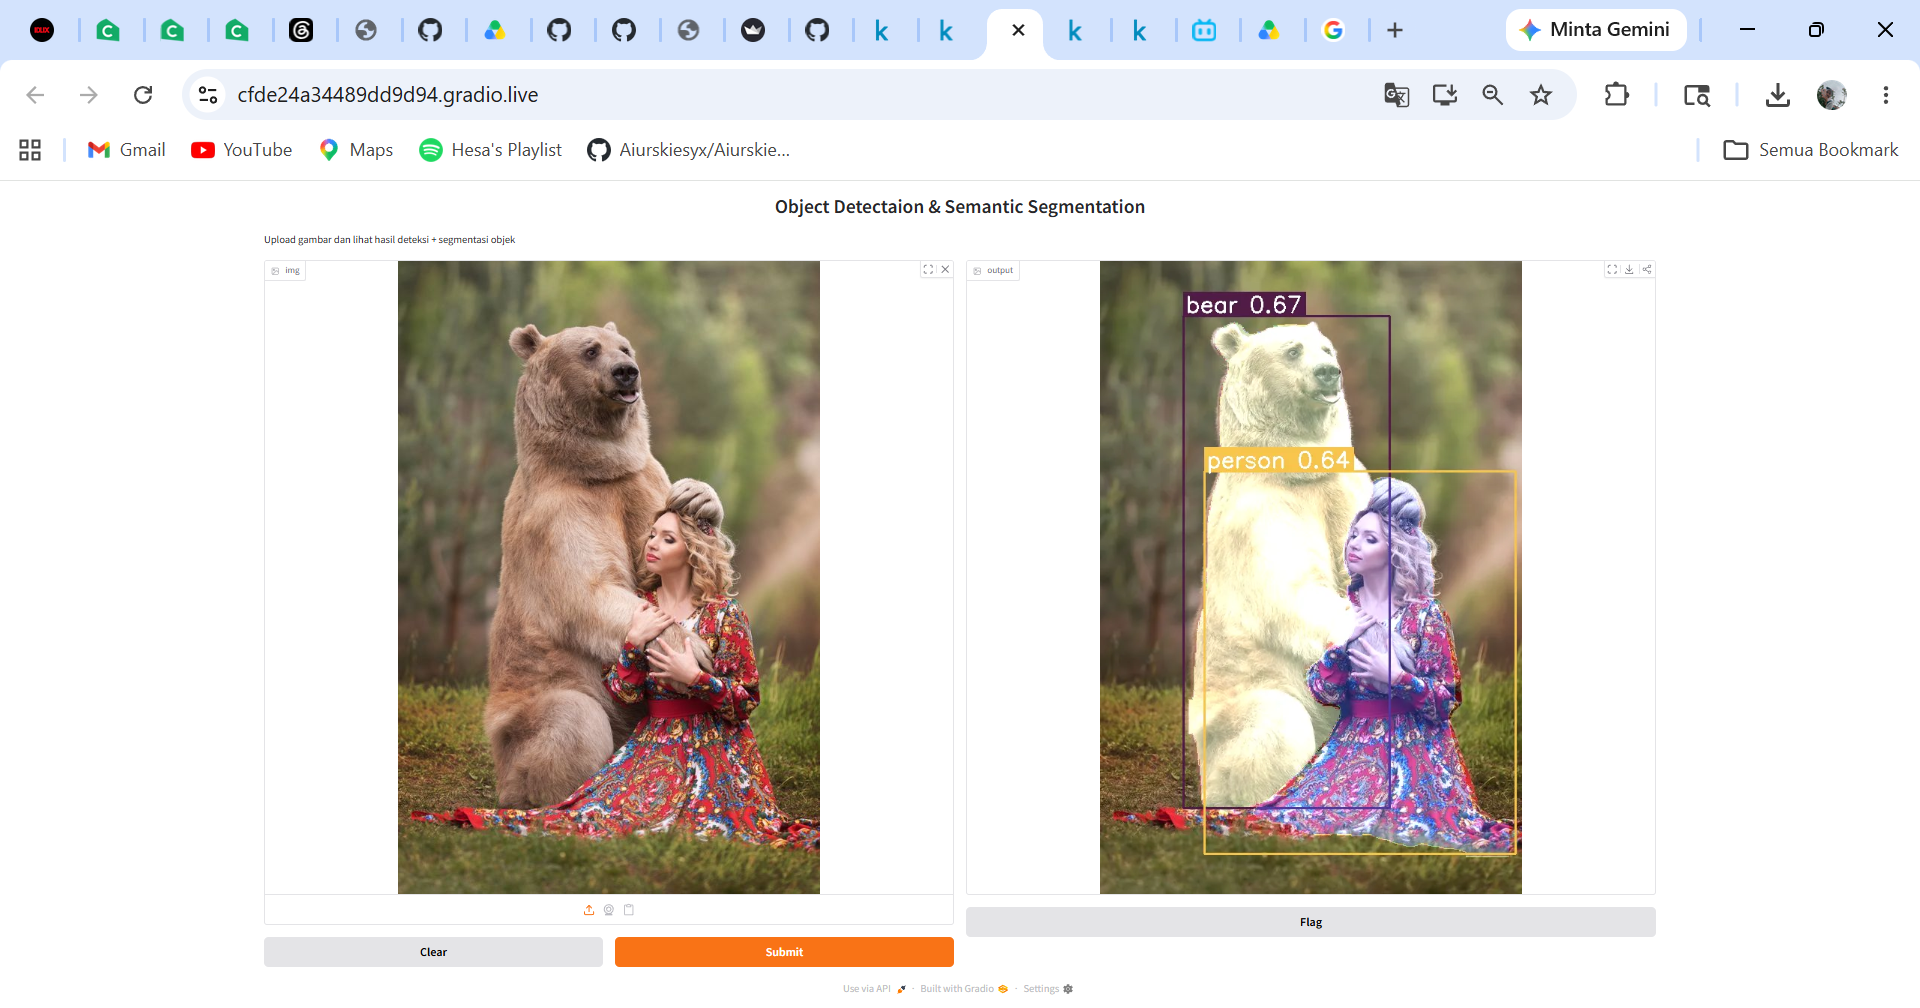

- Terlihat model berhasil mengenali objek `person` dan `bear`.
- Setiap objek dilengkapi dengan bounding box, label, confidence, dan segmentasi mask berwarna.

📌 *Model menggunakan YOLOv8 pre-trained + Gradio frontend untuk upload gambar & visualisasi langsung.*
